### MNIST Classifier

In this notebook, we will implement a CNN classifier to classify all the 10 digits the MNIST dataset. The objective of this lesson is twofold:
* To build our first CNN classifier.
* To use cross-entropy as classification loss.

Let's start with the ususal imports.

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

#### Dataset Loading

We have already inspected the MNIST dataset. We are going to load it now since we are going to use it for training the classifier.

In [6]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Dataset params
num_classes = 10
size = x_train.shape[1]

# Normalization
x_train = x_train/255
x_test = x_test/255

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


#### Building the Classifier

We are going to build the same CNN classifier as before but note that we are using the softmax activation in the last layer (classification head).

In [10]:
inputs = Input(shape=(size, size, 1))

net = Conv2D(16, kernel_size=(3, 3), activation="relu")(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(32, kernel_size=(3, 3), activation="relu")(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Flatten()(net)
outputs = Dense(num_classes, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,810 (50.04 KB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 0 (0.00 B)

#### Training

Let's now compile and train the model. We will use the cross-entropy loss for this task. And note that we can use the built-in accuracy metric for monitoring the training.

In [13]:
epochs = 25
batch_size = 128

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

start = time()
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
print('Elapsed time', time() - start)

Epoch 1/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8956 - loss: 0.3783 - val_accuracy: 0.9742 - val_loss: 0.1002
Epoch 2/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9718 - loss: 0.0960 - val_accuracy: 0.9788 - val_loss: 0.0755
Epoch 3/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9787 - loss: 0.0712 - val_accuracy: 0.9822 - val_loss: 0.0663
Epoch 4/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9819 - loss: 0.0594 - val_accuracy: 0.9830 - val_loss: 0.0601
Epoch 5/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9847 - loss: 0.0518 - val_accuracy: 0.9848 - val_loss: 0.0557
Epoch 6/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9862 - loss: 0.0460 - val_accuracy: 0.9858 - val_loss: 0.0519
Epoch 7/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9873 - loss: 0.0413 - val_accuracy: 0.9867 - val_loss: 0.0489
Epoch 8/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9886 - loss: 0.0374 - val_acc

Let's now plot the history to see the evolution of the training.

Train Acc      0.9977777600288391
Validation Acc 0.987500011920929


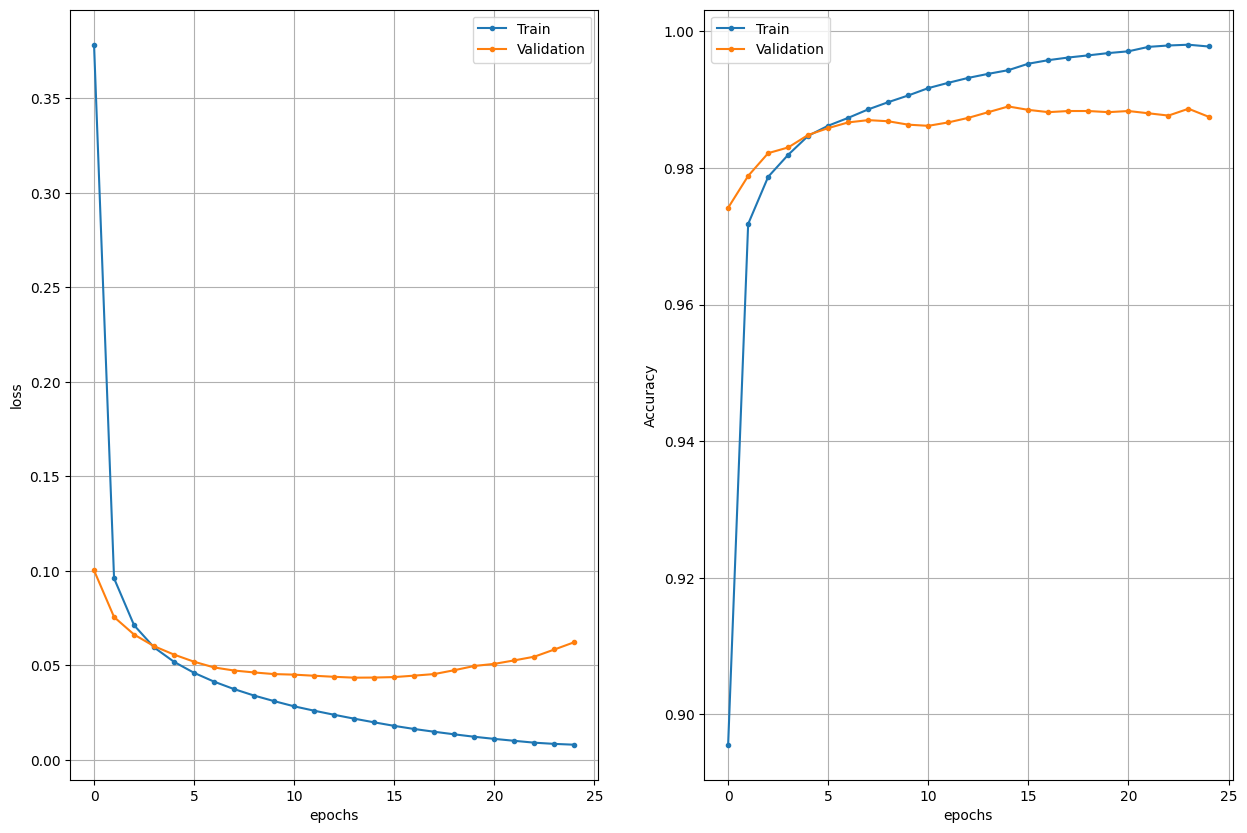

In [16]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
        
    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])
    
plot_history(history)

We have obtained an overall accuracy of about 99%. This might seem lower than we obtained using the binary classifier before but remember we are now classifying **all 10 digits**.

In [19]:
y_true = np.argmax(y_test, axis=1)
y_pred = model.predict(x_test)

print('True', y_true[0:5])
print('Pred', np.argmax(y_pred[0:5, :], axis=1))
print('Pred', y_pred[0:5, :])
print(y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
True [7 2 1 0 4]
Pred [7 2 1 0 4]
Pred [[2.6301586e-15 5.6140558e-13 1.2934459e-08 5.8723430e-07 7.5647161e-21
  8.0264325e-15 1.0631891e-26 9.9999934e-01 3.0853925e-13 1.1205976e-08]
 [5.3937486e-17 2.3534005e-12 9.9999994e-01 3.0544465e-18 1.8608022e-19
  5.7834107e-22 1.2627298e-12 5.9797764e-23 4.2952733e-12 2.5884866e-21]
 [2.5149721e-08 9.9999601e-01 9.0290060e-09 1.3268540e-10 1.2004712e-06
  1.7346887e-09 1.3555832e-07 2.2533814e-06 3.2810325e-07 1.2022326e-09]
 [9.9999970e-01 1.8447511e-19 6.4871920e-13 3.2935773e-15 4.1131725e-17
  3.1680551e-15 2.2216415e-07 4.8332069e-14 1.4486117e-14 1.9529422e-13]
 [2.5084434e-15 7.7994534e-16 3.5816007e-12 5.3064341e-12 9.9999994e-01
  1.1275810e-16 2.8760915e-12 3.6225151e-11 2.1028436e-10 4.6220645e-08]]
(10000, 10)


In [21]:
digits = range(0, 10)
y_pred = np.argmax(y_pred, axis=1)

for digit in digits:
    mask = y_true == digit
    
    tp = np.sum(y_pred[mask] == digit)
    total = np.sum(mask)
    
    print('Digit-', digit, ' acc', tp/total)
    
print('y_true', y_true[mask])
print('y_pred', y_pred[mask])

Digit- 0  acc 0.9948979591836735
Digit- 1  acc 0.9885462555066079
Digit- 2  acc 0.9883720930232558
Digit- 3  acc 0.9930693069306931
Digit- 4  acc 0.9857433808553971
Digit- 5  acc 0.9786995515695067
Digit- 6  acc 0.988517745302714
Digit- 7  acc 0.9727626459143969
Digit- 8  acc 0.9866529774127311
Digit- 9  acc 0.9851337958374629
y_true [9 9 9 ... 9 9 9]
y_pred [9 9 9 ... 9 9 9]


The trained model can also be quickly evaluated by calling the evaluate method on the test data. It will return the loss and the metric (or metrics).

In [24]:
ev = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9863 - loss: 0.0515


In [26]:
print('Test loss  ', ev[0])
print('Test metric', ev[1])

Test loss   0.0515408031642437
Test metric 0.986299991607666


We now visualise some of the evaluation results.

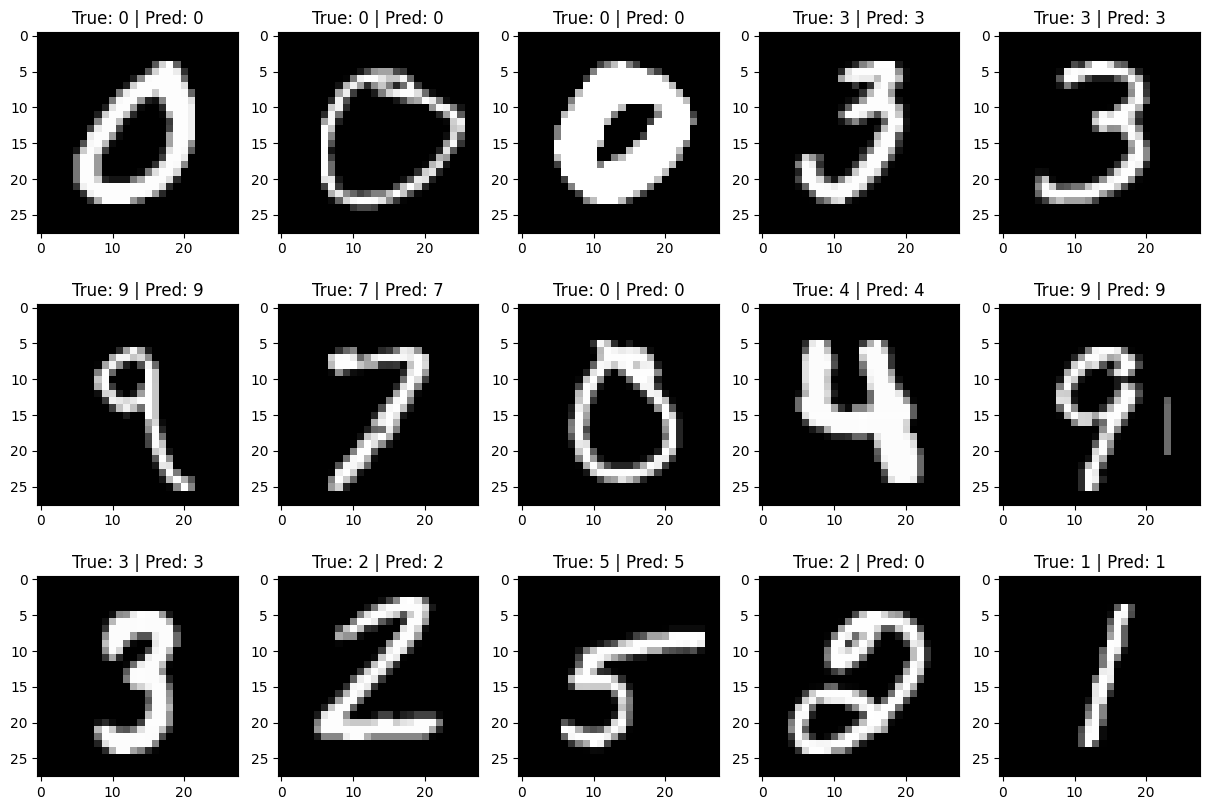

In [29]:
for ii in range(15):
    idx = np.random.randint(0, len(y_pred))
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...], cmap='gray')
    plt.title('True: ' + str(y_true[idx]) + ' | Pred: ' + str(y_pred[idx]))